# Modèle Queue Reactive non-IID - Question 1.2.4

Ce notebook introduit la version Hawkes du modèle queue-reactive.

Dans la question 1.2.3, les ajouts et les retraits avaient des taux de Poisson constants et indépendants. Ici, les ajouts arrivent toujours à taux constant, mais les retraits ont une intensité dynamique de type Hawkes.

Pour une file d'attente :

```text
N(t) = N(0) + N_plus(t) - N_minus(t)
lambda_plus(t) = mu_plus
lambda_minus(t) = mu_minus + integral phi(t-s) dN_plus(s) - integral phi(t-s) dN_minus(s)
phi(u) = alpha exp(-beta u)
```

Ainsi, les ajouts augmentent temporairement l'intensité de retrait, tandis que les retraits la diminuent temporairement.

Le PDF du projet contient une ambiguïté de signe entre la formule affichée et le complément théorique donné plus loin. Ici, on suit le complément `Hawkes 1d` et la Figure 4 de l'énoncé, qui donnent la formule stationnaire utilisée ci-dessous.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist

rng = np.random.default_rng(42)

## 1. Paramètres

On utilise l'exemple numérique présenté dans l'énoncé du projet, Figure 4 :

```text
eta = alpha / beta
```

Le complément théorique rappelle la condition de stabilité usuelle pour un noyau signé, `eta < 1`. L'exemple de l'énoncé utilise `eta = 1`, donc le notebook conserve un petit plancher de non-négativité pour l'intensité pendant la simulation.

In [2]:
# Initial queue size
q0 = 10

# Constant arrival intensity
mu_plus = 1.0

# Baseline removal intensity
mu_minus = 1.1

# Hawkes exponential kernel phi(t) = alpha * exp(-beta * t)
alpha = 0.50
beta = 0.50

# Numerical safeguard: intensities must be non-negative
lambda_floor = 1e-8

eta = alpha / beta

print(f"eta = alpha / beta = {eta:.3f}")
print("Strict eta < 1 condition satisfied:", eta < 1)

eta = alpha / beta = 1.000
Strict eta < 1 condition satisfied: False


## 2. Intensité moyenne stationnaire

En ignorant le plancher de positivité, l'intensité moyenne stationnaire de retrait vérifie une équation de point fixe.

On note

```text
m_minus = E[lambda_minus(t)]
```

Comme les ajouts ont une intensité moyenne `mu_plus`, les retraits ont une intensité moyenne `m_minus`, et la masse totale du noyau vaut `alpha / beta`, on obtient :

```text
m_minus = mu_minus + eta * mu_plus - eta * m_minus
```

Donc :

```text
m_minus = (mu_minus + eta * mu_plus) / (1 + eta)
```

C'est cette quantité que l'on compare à la simulation empirique.

In [3]:
def theoretical_stationary_lambda_minus(mu_plus, mu_minus, alpha, beta):
    eta = alpha / beta
    return (mu_minus + eta * mu_plus) / (1.0 + eta)


lambda_minus_theory = theoretical_stationary_lambda_minus(mu_plus, mu_minus, alpha, beta)

print(f"Theoretical stationary E[lambda_minus] = {lambda_minus_theory:.4f}")

Theoretical stationary E[lambda_minus] = 1.0500


## 3. Simulation exacte des événements par amincissement

La variable de mémoire est :

```text
memory(t) = integral phi(t-s) dN_plus(s) - integral phi(t-s) dN_minus(s)
lambda_minus(t) = mu_minus + memory(t)
```

Entre deux événements, la mémoire décroît exponentiellement :

```text
memory <- memory * exp(-beta * dt)
```

Lors d'un événement d'ajout :

```text
N <- N + 1
memory <- memory + alpha
```

Lors d'un événement de retrait :

```text
N <- N - 1
memory <- memory - alpha
```

On utilise un amincissement adaptatif, c'est-à-dire la version événement par événement de la `simulation par choc fictif` vue en cours, car l'intensité change continûment entre les sauts.

In [4]:
def lambda_minus_from_memory(memory, mu_minus, lambda_floor=1e-8):
    return max(mu_minus + memory, lambda_floor)


def total_rate_upper_bound(memory, mu_plus, mu_minus, lambda_floor=1e-8):
    # Between events, positive memory decays downward and negative memory decays upward.
    # Hence the largest possible removal intensity before the next event is either
    # the current value, if memory > 0, or the baseline mu_minus, if memory < 0.
    upper_lambda_minus = max(mu_minus + max(memory, 0.0), mu_minus, lambda_floor)
    return mu_plus + upper_lambda_minus


def simulate_one_hawkes_queue(
    q0,
    mu_plus,
    mu_minus,
    alpha,
    beta,
    rng=None,
    t_max=10_000.0,
    stop_at_zero=True,
    lambda_floor=1e-8,
    max_events=1_000_000,
):
    """Simulate one queue with constant arrivals and Hawkes-type removals."""
    if rng is None:
        rng = np.random.default_rng()

    t = 0.0
    q = int(q0)
    memory = 0.0

    times = [t]
    queue = [q]
    lambda_minus_path = [lambda_minus_from_memory(memory, mu_minus, lambda_floor)]
    event_types = []
    arrival_times = []
    removal_times = []

    for _ in range(max_events):
        if stop_at_zero and q <= 0:
            break

        upper_rate = total_rate_upper_bound(memory, mu_plus, mu_minus, lambda_floor)
        dt = rng.exponential(1.0 / upper_rate)

        if t + dt > t_max:
            memory *= math.exp(-beta * (t_max - t))
            t = t_max
            times.append(t)
            queue.append(q)
            lambda_minus_path.append(lambda_minus_from_memory(memory, mu_minus, lambda_floor))
            break

        candidate_memory = memory * math.exp(-beta * dt)
        candidate_lambda_minus = lambda_minus_from_memory(candidate_memory, mu_minus, lambda_floor)
        candidate_total_rate = mu_plus + candidate_lambda_minus

        # Accept or reject the candidate event.
        if rng.random() > candidate_total_rate / upper_rate:
            t += dt
            memory = candidate_memory
            continue

        t += dt
        memory = candidate_memory

        if rng.random() < mu_plus / candidate_total_rate:
            q += 1
            memory += alpha
            event_types.append("arrival")
            arrival_times.append(t)
        else:
            q -= 1
            memory -= alpha
            event_types.append("removal")
            removal_times.append(t)

        times.append(t)
        queue.append(q)
        lambda_minus_path.append(lambda_minus_from_memory(memory, mu_minus, lambda_floor))

        if stop_at_zero and q <= 0:
            break
    else:
        raise RuntimeError("max_events reached before the simulation finished")

    tau_zero = t if q <= 0 else np.nan

    return {
        "times": np.asarray(times),
        "queue": np.asarray(queue, dtype=int),
        "lambda_minus": np.asarray(lambda_minus_path),
        "event_types": np.asarray(event_types),
        "arrival_times": np.asarray(arrival_times),
        "removal_times": np.asarray(removal_times),
        "tau_zero": tau_zero,
        "hit_zero": q <= 0,
    }

## 4. Exemple d'une trajectoire

Ce graphique montre une trajectoire de file et son intensité dynamique de retrait. On remarque que `lambda_minus(t)` n'est plus constante : elle réagit aux ajouts et retraits récents.

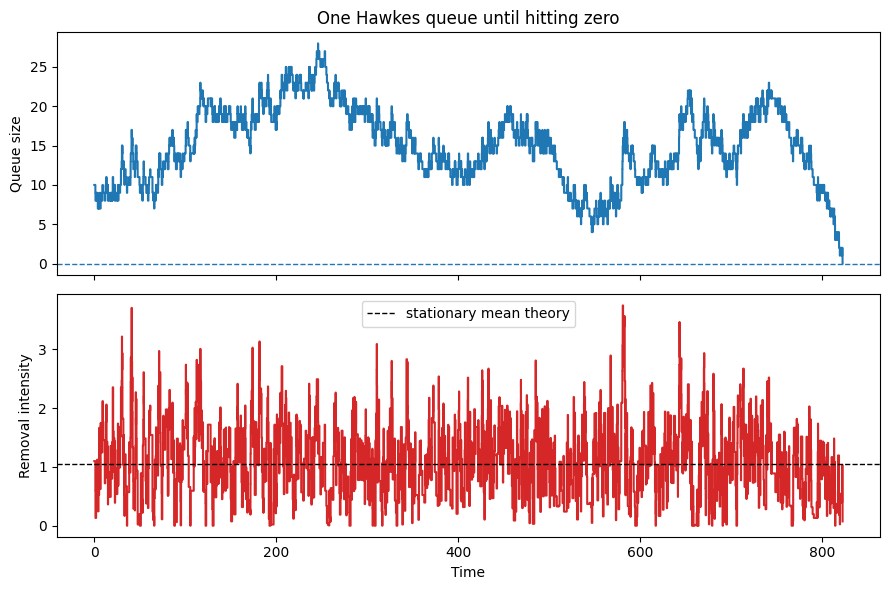

Hit zero: True
tau_zero = 822.8153


In [5]:
sample = simulate_one_hawkes_queue(
    q0=q0,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    rng=rng,
    t_max=5_000.0,
    stop_at_zero=True,
    lambda_floor=lambda_floor,
)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].step(sample["times"], sample["queue"], where="post")
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_ylabel("Queue size")
axes[0].set_title("One Hawkes queue until hitting zero")

axes[1].step(sample["times"], sample["lambda_minus"], where="post", color="tab:red")
axes[1].axhline(lambda_minus_theory, linestyle="--", linewidth=1, color="black", label="stationary mean theory")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Removal intensity")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Hit zero: {sample['hit_zero']}")
print(f"tau_zero = {sample['tau_zero']:.4f}")

## 5. Intensité stationnaire empirique de retrait

Pour estimer l'intensité moyenne stationnaire de retrait, on simule le flux d'événements Hawkes sur un horizon long et on estime :

```text
nombre de retraits après burn-in / temps d'observation après burn-in
```

Pour cette estimation du taux stationnaire, on ne s'arrête pas lorsque la file atteint zéro. On estime ici l'intensité de long terme du flux d'ordres, et non l'expérience absorbante de temps d'atteinte.

Theoretical stationary rate = 1.0500
Empirical stationary rate   = 1.0510


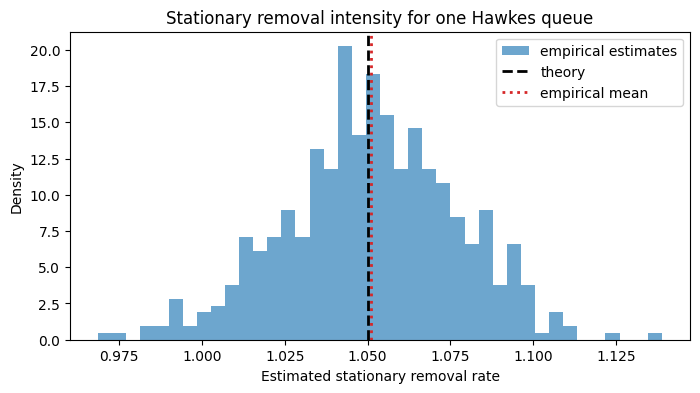

In [6]:
def estimate_stationary_removal_rates(
    n_paths,
    mu_plus,
    mu_minus,
    alpha,
    beta,
    rng=None,
    t_max=1_000.0,
    burn_in=200.0,
):
    if rng is None:
        rng = np.random.default_rng()

    estimates = np.empty(n_paths)
    for k in range(n_paths):
        out = simulate_one_hawkes_queue(
            q0=0,
            mu_plus=mu_plus,
            mu_minus=mu_minus,
            alpha=alpha,
            beta=beta,
            rng=rng,
            t_max=t_max,
            stop_at_zero=False,
            lambda_floor=lambda_floor,
        )
        n_removals = np.sum(out["removal_times"] >= burn_in)
        estimates[k] = n_removals / (t_max - burn_in)

    return estimates


stationary_estimates = estimate_stationary_removal_rates(
    n_paths=500,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    rng=rng,
    t_max=1_000.0,
    burn_in=200.0,
)

empirical_mean_lambda_minus = stationary_estimates.mean()

print(f"Theoretical stationary rate = {lambda_minus_theory:.4f}")
print(f"Empirical stationary rate   = {empirical_mean_lambda_minus:.4f}")

plt.figure(figsize=(8, 4))
plt.hist(stationary_estimates, bins=40, density=True, alpha=0.65, label="empirical estimates")
plt.axvline(lambda_minus_theory, color="black", linestyle="--", linewidth=2, label="theory")
plt.axvline(empirical_mean_lambda_minus, color="tab:red", linestyle=":", linewidth=2, label="empirical mean")
plt.xlabel("Estimated stationary removal rate")
plt.ylabel("Density")
plt.title("Stationary removal intensity for one Hawkes queue")
plt.legend()
plt.show()

## 6. Distribution des temps d'atteinte

On répond maintenant à la deuxième partie pour une seule file :

```text
Estimer la distribution du temps auquel la file Hawkes atteint zéro pour la première fois.
```

Pour chaque trajectoire Monte Carlo, on simule la file jusqu'à :

```text
tau = inf { t >= 0 : N(t) <= 0 }
```

On trace ensuite la distribution empirique de `tau`.

Hit probability in simulation = 1.0000
Mean hitting time = 180.3531
95% CI = [173.5005, 187.2056]


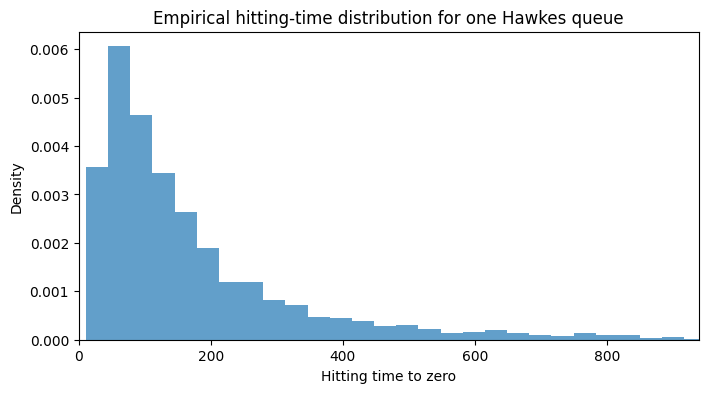

In [7]:
def sample_hawkes_hitting_times(
    n_samples,
    q0,
    mu_plus,
    mu_minus,
    alpha,
    beta,
    rng=None,
    t_max=10_000.0,
):
    if rng is None:
        rng = np.random.default_rng()

    tau = np.empty(n_samples)
    hit = np.empty(n_samples, dtype=bool)

    for k in range(n_samples):
        out = simulate_one_hawkes_queue(
            q0=q0,
            mu_plus=mu_plus,
            mu_minus=mu_minus,
            alpha=alpha,
            beta=beta,
            rng=rng,
            t_max=t_max,
            stop_at_zero=True,
            lambda_floor=lambda_floor,
        )
        tau[k] = out["tau_zero"]
        hit[k] = out["hit_zero"]

    return tau, hit


def mean_confidence_interval(x, level=0.95):
    x = np.asarray(x, dtype=float)
    n = len(x)
    mean = x.mean()
    s = x.std(ddof=1)
    z = NormalDist().inv_cdf(0.5 + level / 2.0)
    half_width = z * s / math.sqrt(n)
    return mean, mean - half_width, mean + half_width


hawkes_tau, hawkes_hit = sample_hawkes_hitting_times(
    n_samples=3_000,
    q0=q0,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    rng=rng,
    t_max=10_000.0,
)

finite_tau = hawkes_tau[np.isfinite(hawkes_tau)]
mean_tau, ci_low, ci_high = mean_confidence_interval(finite_tau)

print(f"Hit probability in simulation = {hawkes_hit.mean():.4f}")
print(f"Mean hitting time = {mean_tau:.4f}")
print(f"95% CI = [{ci_low:.4f}, {ci_high:.4f}]")

upper = np.quantile(finite_tau, 0.99)

plt.figure(figsize=(8, 4))
plt.hist(finite_tau, bins=60, density=True, alpha=0.7)
plt.xlim(0, upper)
plt.xlabel("Hitting time to zero")
plt.ylabel("Density")
plt.title("Empirical hitting-time distribution for one Hawkes queue")
plt.show()

## 7. Deux files Hawkes couplées

On répond maintenant à la partie couplée de la question 1.2.4.

On simule deux files d'attente :

```text
Q_bid(t) = Q_bid(0) + N_bid_plus(t) - N_bid_minus(t)
Q_ask(t) = Q_ask(0) + N_ask_plus(t) - N_ask_minus(t)
```

Les ajouts restent constants des deux côtés. Les retraits sont dynamiques :

```text
lambda_bid_minus(t) = mu_minus + memory_bid(t) + gamma_cross * memory_ask(t)
lambda_ask_minus(t) = mu_minus + memory_ask(t) + gamma_cross * memory_bid(t)
```

Le paramètre `gamma_cross` contrôle l'intensité avec laquelle le côté opposé influence le côté courant. L'énoncé utilise le même noyau pour la file opposée ; ici cela correspond à `gamma_cross = 1`.

In [8]:
gamma_cross = 1.0


def coupled_stationary_lambda_minus(mu_plus, mu_minus, alpha, beta, gamma_cross=1.0):
    eta = alpha / beta
    influence = (1.0 + gamma_cross) * eta
    return (mu_minus + influence * mu_plus) / (1.0 + influence)


lambda_minus_coupled_theory = coupled_stationary_lambda_minus(
    mu_plus, mu_minus, alpha, beta, gamma_cross=gamma_cross
)

print(f"gamma_cross = {gamma_cross:.2f}")
print(f"Theoretical coupled stationary E[lambda_minus] = {lambda_minus_coupled_theory:.4f}")


def two_queue_intensities(memory_bid, memory_ask, mu_plus, mu_minus, gamma_cross=1.0, lambda_floor=1e-8):
    bid_minus_signal = memory_bid + gamma_cross * memory_ask
    ask_minus_signal = memory_ask + gamma_cross * memory_bid

    lambda_bid_plus = mu_plus
    lambda_ask_plus = mu_plus
    lambda_bid_minus = max(mu_minus + bid_minus_signal, lambda_floor)
    lambda_ask_minus = max(mu_minus + ask_minus_signal, lambda_floor)

    return lambda_bid_plus, lambda_bid_minus, lambda_ask_plus, lambda_ask_minus


def two_queue_total_rate_upper_bound(memory_bid, memory_ask, mu_plus, mu_minus, gamma_cross=1.0, lambda_floor=1e-8):
    bid_signal = memory_bid + gamma_cross * memory_ask
    ask_signal = memory_ask + gamma_cross * memory_bid

    upper_bid_minus = max(mu_minus + max(bid_signal, 0.0), mu_minus, lambda_floor)
    upper_ask_minus = max(mu_minus + max(ask_signal, 0.0), mu_minus, lambda_floor)

    return 2.0 * mu_plus + upper_bid_minus + upper_ask_minus


def simulate_two_coupled_hawkes_queues(
    q_bid0,
    q_ask0,
    mu_plus,
    mu_minus,
    alpha,
    beta,
    gamma_cross=1.0,
    rng=None,
    t_max=10_000.0,
    stop_at_zero=True,
    lambda_floor=1e-8,
    max_events=2_000_000,
):
    """Simulate bid and ask queues with coupled Hawkes removal intensities."""
    if rng is None:
        rng = np.random.default_rng()

    t = 0.0
    q_bid = int(q_bid0)
    q_ask = int(q_ask0)
    memory_bid = 0.0
    memory_ask = 0.0

    times = [t]
    bid_path = [q_bid]
    ask_path = [q_ask]
    bid_minus_path = []
    ask_minus_path = []
    event_types = []
    bid_removal_times = []
    ask_removal_times = []

    _, lbm, _, lam = two_queue_intensities(
        memory_bid, memory_ask, mu_plus, mu_minus, gamma_cross, lambda_floor
    )
    bid_minus_path.append(lbm)
    ask_minus_path.append(lam)

    for _ in range(max_events):
        if stop_at_zero and (q_bid <= 0 or q_ask <= 0):
            break

        upper_rate = two_queue_total_rate_upper_bound(
            memory_bid, memory_ask, mu_plus, mu_minus, gamma_cross, lambda_floor
        )
        dt = rng.exponential(1.0 / upper_rate)

        if t + dt > t_max:
            decay = math.exp(-beta * (t_max - t))
            memory_bid *= decay
            memory_ask *= decay
            t = t_max
            times.append(t)
            bid_path.append(q_bid)
            ask_path.append(q_ask)
            _, lbm, _, lam = two_queue_intensities(
                memory_bid, memory_ask, mu_plus, mu_minus, gamma_cross, lambda_floor
            )
            bid_minus_path.append(lbm)
            ask_minus_path.append(lam)
            break

        decay = math.exp(-beta * dt)
        candidate_memory_bid = memory_bid * decay
        candidate_memory_ask = memory_ask * decay

        intensities = two_queue_intensities(
            candidate_memory_bid,
            candidate_memory_ask,
            mu_plus,
            mu_minus,
            gamma_cross,
            lambda_floor,
        )
        lambda_bid_plus, lambda_bid_minus, lambda_ask_plus, lambda_ask_minus = intensities
        candidate_total_rate = sum(intensities)

        if rng.random() > candidate_total_rate / upper_rate:
            t += dt
            memory_bid = candidate_memory_bid
            memory_ask = candidate_memory_ask
            continue

        t += dt
        memory_bid = candidate_memory_bid
        memory_ask = candidate_memory_ask

        u = rng.random() * candidate_total_rate
        if u < lambda_bid_plus:
            q_bid += 1
            memory_bid += alpha
            event_types.append("bid_arrival")
        elif u < lambda_bid_plus + lambda_bid_minus:
            q_bid -= 1
            memory_bid -= alpha
            event_types.append("bid_removal")
            bid_removal_times.append(t)
        elif u < lambda_bid_plus + lambda_bid_minus + lambda_ask_plus:
            q_ask += 1
            memory_ask += alpha
            event_types.append("ask_arrival")
        else:
            q_ask -= 1
            memory_ask -= alpha
            event_types.append("ask_removal")
            ask_removal_times.append(t)

        times.append(t)
        bid_path.append(q_bid)
        ask_path.append(q_ask)
        _, lbm, _, lam = two_queue_intensities(
            memory_bid, memory_ask, mu_plus, mu_minus, gamma_cross, lambda_floor
        )
        bid_minus_path.append(lbm)
        ask_minus_path.append(lam)

        if stop_at_zero and (q_bid <= 0 or q_ask <= 0):
            break
    else:
        raise RuntimeError("max_events reached before the simulation finished")

    if q_bid <= 0 and q_ask <= 0:
        first_queue = "both"
    elif q_bid <= 0:
        first_queue = "bid"
    elif q_ask <= 0:
        first_queue = "ask"
    else:
        first_queue = None

    return {
        "times": np.asarray(times),
        "bid": np.asarray(bid_path, dtype=int),
        "ask": np.asarray(ask_path, dtype=int),
        "lambda_bid_minus": np.asarray(bid_minus_path),
        "lambda_ask_minus": np.asarray(ask_minus_path),
        "event_types": np.asarray(event_types),
        "bid_removal_times": np.asarray(bid_removal_times),
        "ask_removal_times": np.asarray(ask_removal_times),
        "tau_first": t if first_queue is not None else np.nan,
        "first_queue": first_queue,
        "hit_zero": first_queue is not None,
    }

gamma_cross = 1.00
Theoretical coupled stationary E[lambda_minus] = 1.0333


## 8. Exemple de trajectoire couplée

C'est l'analogue à deux files de la trajectoire précédente. On s'arrête dès que la file bid ou la file ask atteint zéro.

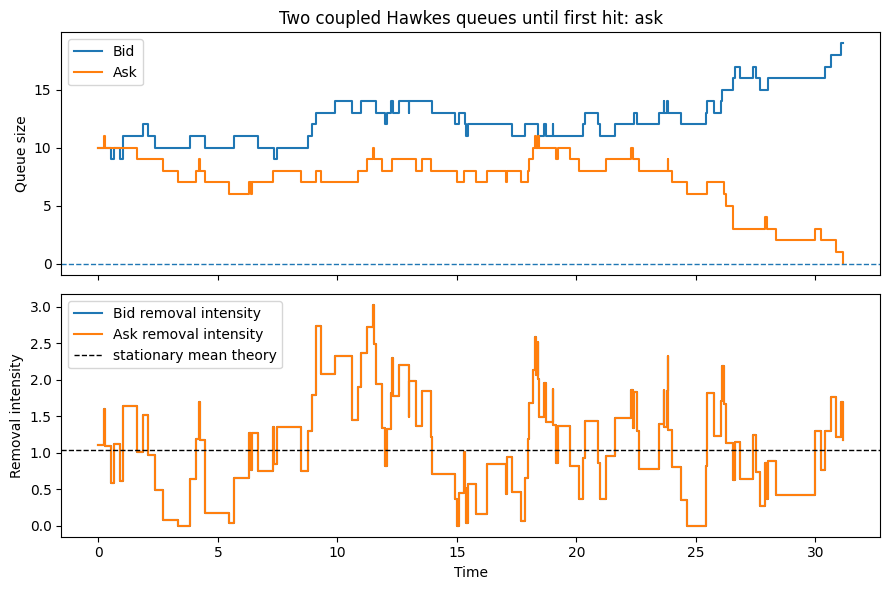

First queue to hit zero = ask
tau_first = 31.1506


In [9]:
sample_two = simulate_two_coupled_hawkes_queues(
    q_bid0=q0,
    q_ask0=q0,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    gamma_cross=gamma_cross,
    rng=rng,
    t_max=5_000.0,
    stop_at_zero=True,
    lambda_floor=lambda_floor,
)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].step(sample_two["times"], sample_two["bid"], where="post", label="Bid")
axes[0].step(sample_two["times"], sample_two["ask"], where="post", label="Ask")
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_ylabel("Queue size")
axes[0].set_title(f"Two coupled Hawkes queues until first hit: {sample_two['first_queue']}")
axes[0].legend()

axes[1].step(sample_two["times"], sample_two["lambda_bid_minus"], where="post", label="Bid removal intensity")
axes[1].step(sample_two["times"], sample_two["lambda_ask_minus"], where="post", label="Ask removal intensity")
axes[1].axhline(lambda_minus_coupled_theory, linestyle="--", linewidth=1, color="black", label="stationary mean theory")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Removal intensity")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"First queue to hit zero = {sample_two['first_queue']}")
print(f"tau_first = {sample_two['tau_first']:.4f}")

## 9. Intensité stationnaire du modèle couplé

Pour le modèle couplé symétrique, l'approximation théorique par point fixe est :

```text
m_minus = mu_minus + (1 + gamma_cross) eta (mu_plus - m_minus)
```

d'où :

```text
m_minus = (mu_minus + (1 + gamma_cross) eta mu_plus) / (1 + (1 + gamma_cross) eta)
```

Theoretical coupled stationary rate = 1.0333
Empirical coupled stationary rate   = 1.0325


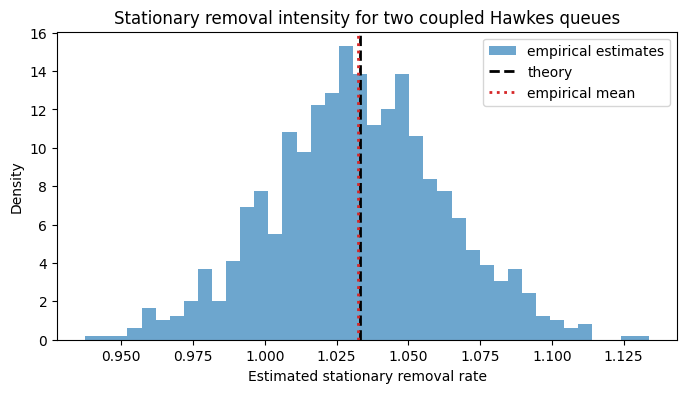

In [10]:
def estimate_coupled_stationary_removal_rates(
    n_paths,
    mu_plus,
    mu_minus,
    alpha,
    beta,
    gamma_cross=1.0,
    rng=None,
    t_max=1_000.0,
    burn_in=200.0,
):
    if rng is None:
        rng = np.random.default_rng()

    estimates = np.empty((n_paths, 2))
    for k in range(n_paths):
        out = simulate_two_coupled_hawkes_queues(
            q_bid0=0,
            q_ask0=0,
            mu_plus=mu_plus,
            mu_minus=mu_minus,
            alpha=alpha,
            beta=beta,
            gamma_cross=gamma_cross,
            rng=rng,
            t_max=t_max,
            stop_at_zero=False,
            lambda_floor=lambda_floor,
        )
        estimates[k, 0] = np.sum(out["bid_removal_times"] >= burn_in) / (t_max - burn_in)
        estimates[k, 1] = np.sum(out["ask_removal_times"] >= burn_in) / (t_max - burn_in)

    return estimates


coupled_stationary_estimates = estimate_coupled_stationary_removal_rates(
    n_paths=500,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    gamma_cross=gamma_cross,
    rng=rng,
    t_max=1_000.0,
    burn_in=200.0,
)

coupled_stationary_flat = coupled_stationary_estimates.ravel()
empirical_coupled_rate = coupled_stationary_flat.mean()

print(f"Theoretical coupled stationary rate = {lambda_minus_coupled_theory:.4f}")
print(f"Empirical coupled stationary rate   = {empirical_coupled_rate:.4f}")

plt.figure(figsize=(8, 4))
plt.hist(coupled_stationary_flat, bins=40, density=True, alpha=0.65, label="empirical estimates")
plt.axvline(lambda_minus_coupled_theory, color="black", linestyle="--", linewidth=2, label="theory")
plt.axvline(empirical_coupled_rate, color="tab:red", linestyle=":", linewidth=2, label="empirical mean")
plt.xlabel("Estimated stationary removal rate")
plt.ylabel("Density")
plt.title("Stationary removal intensity for two coupled Hawkes queues")
plt.legend()
plt.show()

## 10. Premier temps d'atteinte parmi les deux files Hawkes couplées

On estime maintenant :

```text
tau = tau_bid wedge tau_ask
```

Cela répond au quatrième point de la question 1.2.4 : la distribution du premier instant auquel l'une des deux files Hawkes couplées atteint zéro.

Hit probability in simulation = 1.0000
P(ask hits before bid) = 0.5003
Mean first hitting time = 59.5542
95% CI = [57.9348, 61.1736]


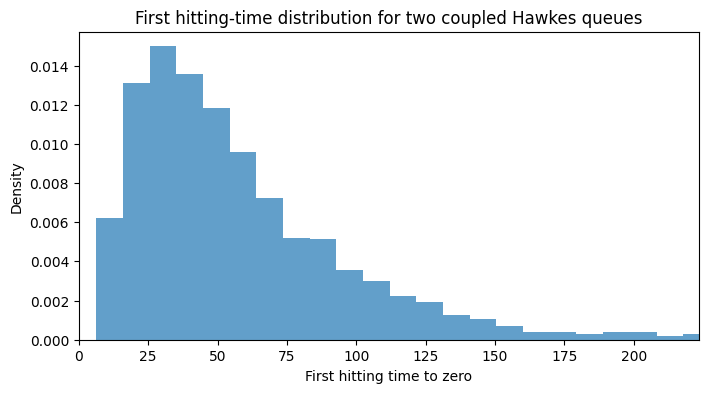

In [11]:
def sample_two_coupled_hawkes_first_hitting_times(
    n_samples,
    q0,
    mu_plus,
    mu_minus,
    alpha,
    beta,
    gamma_cross=1.0,
    rng=None,
    t_max=10_000.0,
):
    if rng is None:
        rng = np.random.default_rng()

    tau = np.empty(n_samples)
    first_queue = np.empty(n_samples, dtype=object)
    hit = np.empty(n_samples, dtype=bool)

    for k in range(n_samples):
        out = simulate_two_coupled_hawkes_queues(
            q_bid0=q0,
            q_ask0=q0,
            mu_plus=mu_plus,
            mu_minus=mu_minus,
            alpha=alpha,
            beta=beta,
            gamma_cross=gamma_cross,
            rng=rng,
            t_max=t_max,
            stop_at_zero=True,
            lambda_floor=lambda_floor,
        )
        tau[k] = out["tau_first"]
        first_queue[k] = out["first_queue"]
        hit[k] = out["hit_zero"]

    return tau, first_queue, hit


two_hawkes_tau, two_hawkes_first_queue, two_hawkes_hit = sample_two_coupled_hawkes_first_hitting_times(
    n_samples=3_000,
    q0=q0,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    gamma_cross=gamma_cross,
    rng=rng,
    t_max=10_000.0,
)

two_hawkes_tau = two_hawkes_tau[np.isfinite(two_hawkes_tau)]
mean_two_hawkes, ci_two_low, ci_two_high = mean_confidence_interval(two_hawkes_tau)

print(f"Hit probability in simulation = {two_hawkes_hit.mean():.4f}")
print(f"P(ask hits before bid) = {np.mean(two_hawkes_first_queue == 'ask'):.4f}")
print(f"Mean first hitting time = {mean_two_hawkes:.4f}")
print(f"95% CI = [{ci_two_low:.4f}, {ci_two_high:.4f}]")

upper = np.quantile(two_hawkes_tau, 0.99)

plt.figure(figsize=(8, 4))
plt.hist(two_hawkes_tau, bins=60, density=True, alpha=0.7)
plt.xlim(0, upper)
plt.xlabel("First hitting time to zero")
plt.ylabel("Density")
plt.title("First hitting-time distribution for two coupled Hawkes queues")
plt.show()

## 11. Comparaison avec les références Poisson

Enfin, on compare quatre cas :

```text
une file Poisson
première de deux files Poisson indépendantes
une file Hawkes
première de deux files Hawkes couplées
```

Pour rendre la comparaison équitable, la référence Poisson ci-dessous utilise le même taux d'arrivée et le même taux moyen stationnaire de retrait que le modèle Hawkes à une file.

Poisson benchmark rates: lambda_plus = 1.0000, lambda_minus = 1.0500

Case                          Mean      CI low    CI high
---------------------------------------------------------
One Poisson                    190.694   177.147   204.241
First of two Poisson            64.726    61.186    68.265
One Hawkes                     180.353   173.501   187.206
First of two coupled Hawkes     59.554    57.935    61.174

Empirical order from fastest to slowest:
First of two coupled Hawkes < First of two Poisson < One Hawkes < One Poisson


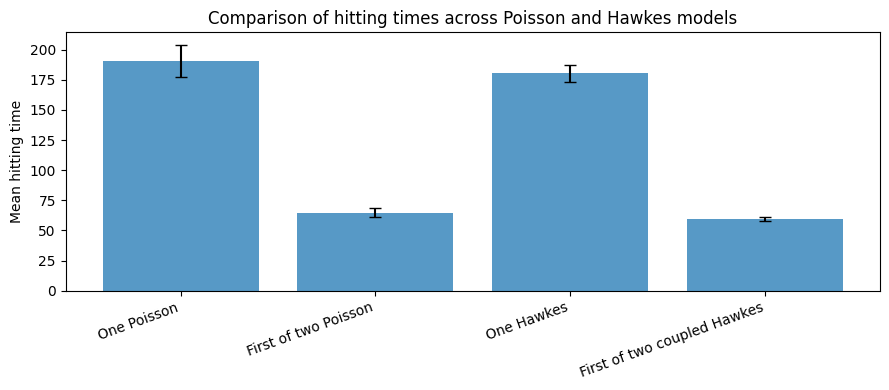

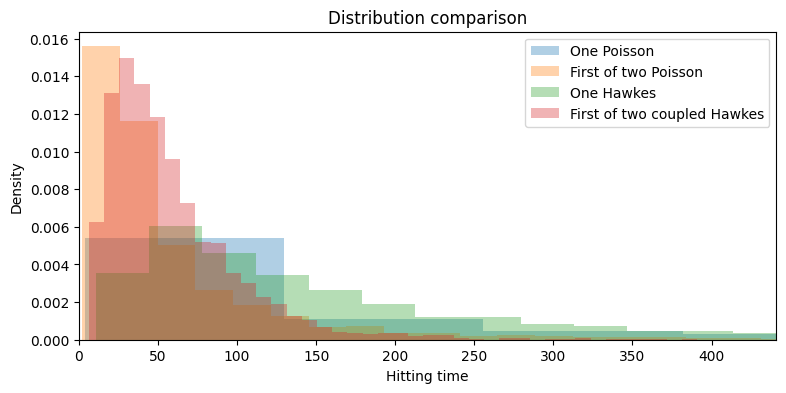

In [12]:
def simulate_poisson_one_queue_until_zero(q0, lambda_plus, lambda_minus, rng=None, max_events=1_000_000):
    if rng is None:
        rng = np.random.default_rng()
    if q0 <= 0:
        return 0.0

    rate = lambda_plus + lambda_minus
    p_up = lambda_plus / rate
    t = 0.0
    q = int(q0)

    for _ in range(max_events):
        t += rng.exponential(1.0 / rate)
        q += 1 if rng.random() < p_up else -1
        if q <= 0:
            return t

    raise RuntimeError("max_events reached before hitting zero")


def sample_poisson_hitting_times(n_samples, q0, lambda_plus, lambda_minus, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    return np.array([
        simulate_poisson_one_queue_until_zero(q0, lambda_plus, lambda_minus, rng=rng)
        for _ in range(n_samples)
    ])


n_comparison = 3_000
poisson_lambda_plus = mu_plus
poisson_lambda_minus = lambda_minus_theory

poisson_one_tau = sample_poisson_hitting_times(
    n_comparison, q0, poisson_lambda_plus, poisson_lambda_minus, rng=rng
)
poisson_two_tau = np.minimum(
    sample_poisson_hitting_times(n_comparison, q0, poisson_lambda_plus, poisson_lambda_minus, rng=rng),
    sample_poisson_hitting_times(n_comparison, q0, poisson_lambda_plus, poisson_lambda_minus, rng=rng),
)

comparison_samples = {
    "One Poisson": poisson_one_tau,
    "First of two Poisson": poisson_two_tau,
    "One Hawkes": finite_tau,
    "First of two coupled Hawkes": two_hawkes_tau,
}

print(f"Poisson benchmark rates: lambda_plus = {poisson_lambda_plus:.4f}, lambda_minus = {poisson_lambda_minus:.4f}")
print()
print("Case                          Mean      CI low    CI high")
print("---------------------------------------------------------")

comparison_means = []
comparison_low = []
comparison_high = []

for name, values in comparison_samples.items():
    m, lo, hi = mean_confidence_interval(values)
    comparison_means.append(m)
    comparison_low.append(lo)
    comparison_high.append(hi)
    print(f"{name:<29} {m:8.3f}  {lo:8.3f}  {hi:8.3f}")

order = sorted(comparison_samples, key=lambda name: np.mean(comparison_samples[name]))
print()
print("Empirical order from fastest to slowest:")
print(" < ".join(order))

labels = list(comparison_samples.keys())
means = np.asarray(comparison_means)
err_low = means - np.asarray(comparison_low)
err_high = np.asarray(comparison_high) - means

plt.figure(figsize=(9, 4))
plt.bar(labels, means, yerr=[err_low, err_high], capsize=4, alpha=0.75)
plt.ylabel("Mean hitting time")
plt.title("Comparison of hitting times across Poisson and Hawkes models")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

upper = np.quantile(np.concatenate(list(comparison_samples.values())), 0.95)
plt.figure(figsize=(9, 4))
for name, values in comparison_samples.items():
    plt.hist(values, bins=60, density=True, alpha=0.35, label=name)
plt.xlim(0, upper)
plt.xlabel("Hitting time")
plt.ylabel("Density")
plt.title("Distribution comparison")
plt.legend()
plt.show()